In [1]:
"""
MODEL EXPERIMENTATION FOR ANALOG CIRCUIT PARAMETER PREDICTION
==============================================================

Goal: Compare different ML models to find the best ones for:
  - Model 1: (a,b,c,d) → gain
  - Model 2: (a,b,c,d) → pm
  - Model 3: (a,b,c,d) → ugf

Models to Compare:
  1. Linear Regression (baseline)
  2. Ridge Regression
  3. Random Forest
  4. Gradient Boosting (XGBoost & LightGBM)
  5. Neural Network (MLP)
  6. Support Vector Regression (SVR)
"""

'\nMODEL EXPERIMENTATION FOR ANALOG CIRCUIT PARAMETER PREDICTION\n==============================================================\n\nGoal: Compare different ML models to find the best ones for:\n  - Model 1: (a,b,c,d) → gain\n  - Model 2: (a,b,c,d) → pm\n  - Model 3: (a,b,c,d) → ugf\n\nModels to Compare:\n  1. Linear Regression (baseline)\n  2. Ridge Regression\n  3. Random Forest\n  4. Gradient Boosting (XGBoost & LightGBM)\n  5. Neural Network (MLP)\n  6. Support Vector Regression (SVR)\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

# Models to test
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# Additional libraries (install if needed)
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except:
    XGBOOST_AVAILABLE = False
    print("⚠ XGBoost not available. Install with: pip install xgboost")

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except:
    LIGHTGBM_AVAILABLE = False
    print("⚠ LightGBM not available. Install with: pip install lightgbm")

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r"D:\UST Project\UST_Analog_automation\data\processed\UpdatedOpam\gain_ml.csv")
dff = pd.read_csv(r"D:\UST Project\UST_Analog_automation\data\processed\UpdatedOpam\pm_ml.csv")
dfff = pd.read_csv(r"D:\UST Project\UST_Analog_automation\data\processed\UpdatedOpam\ugf_ml.csv")

# Features (parameters) and targets (specs)
X = df[['a', 'b', 'c', 'd']].values
y_gain = df['gain'].values
y_pm = dff['pm'].values
y_ugf = dfff['ugf'].values

print(f"Feature matrix X: {X.shape}")
print(f"Target gain: {y_gain.shape}")
print(f"Target pm: {y_pm.shape}")
print(f"Target ugf: {y_ugf.shape}")

# Train-test split (80-20)
X_train, X_test, y_train_gain, y_test_gain = train_test_split(
    X, y_gain, test_size=0.2, random_state=42
)
_, _, y_train_pm, y_test_pm = train_test_split(
    X, y_pm, test_size=0.2, random_state=42
)
_, _, y_train_ugf, y_test_ugf = train_test_split(
    X, y_ugf, test_size=0.2, random_state=42
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Feature scaling (important for some models)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

print("\n✓ Data preparation complete!")

Feature matrix X: (2210, 4)
Target gain: (2210,)
Target pm: (2210,)
Target ugf: (2210,)

Train set: 1768 samples
Test set: 442 samples

✓ Data preparation complete!


In [4]:
# ============================================================================
# STEP 3: DEFINE MODELS TO COMPARE
# ============================================================================

print("\n" + "="*80)
print("STEP 3: DEFINE MODELS")
print("="*80)

models = {
    'Linear Regression': LinearRegression(),
    
    'Ridge': Ridge(alpha=1.0, random_state=42),
    
    'Lasso': Lasso(alpha=1.0, random_state=42),
    
    'Decision Tree': DecisionTreeRegressor(
        max_depth=10, 
        min_samples_split=10,
        random_state=42
    ),
    
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ),
    
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100,
        max_depth=7,
        learning_rate=0.1,
        random_state=42
    ),
    
    'Neural Network (Small)': MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        max_iter=500,
        random_state=42,
        early_stopping=True
    ),
    
    'Neural Network (Large)': MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        max_iter=500,
        random_state=42,
        early_stopping=True
    ),
    
    'SVR': SVR(
        kernel='rbf',
        C=100,
        gamma='scale'
    ),
}

# Add XGBoost if available
if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBRegressor(
        n_estimators=100,
        max_depth=7,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )

# Add LightGBM if available
if LIGHTGBM_AVAILABLE:
    models['LightGBM'] = LGBMRegressor(
        n_estimators=100,
        max_depth=7,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

print(f"✓ Defined {len(models)} models to compare:")
for name in models.keys():
    print(f"  - {name}")



STEP 3: DEFINE MODELS
✓ Defined 11 models to compare:
  - Linear Regression
  - Ridge
  - Lasso
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - Neural Network (Small)
  - Neural Network (Large)
  - SVR
  - XGBoost
  - LightGBM


In [5]:
# ============================================================================
# STEP 4: TRAIN AND EVALUATE ALL MODELS
# ============================================================================

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, target_name):
    """Train and evaluate a single model"""
    
    # Determine if model needs scaled data
    needs_scaling = model_name in ['Ridge', 'Lasso', 'Neural Network (Small)', 
                                   'Neural Network (Large)', 'SVR']
    
    X_tr = X_train_scaled if needs_scaling else X_train
    X_te = X_test_scaled if needs_scaling else X_test
    
    # Train
    model.fit(X_tr, y_train)
    
    # Predict
    y_pred_train = model.predict(X_tr)
    y_pred_test = model.predict(X_te)
    
    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    
    # MAPE (avoid division by zero)
    train_mape = mean_absolute_percentage_error(y_train, y_pred_train) * 100
    test_mape = mean_absolute_percentage_error(y_test, y_pred_test) * 100
    
    return {
        'model_name': model_name,
        'target': target_name,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_mape': train_mape,
        'test_mape': test_mape,
        'predictions': y_pred_test,
        'actuals': y_test
    }

print("\n" + "="*80)
print("STEP 4: TRAINING AND EVALUATING ALL MODELS")
print("="*80)

results = []

# For each target (gain, pm, ugf)
targets = [
    ('gain', y_train_gain, y_test_gain),
    ('pm', y_train_pm, y_test_pm),
    ('ugf', y_train_ugf, y_test_ugf)
]

for target_name, y_train, y_test in targets:
    print(f"\n{'='*80}")
    print(f"TRAINING MODELS FOR: {target_name.upper()}")
    print(f"{'='*80}")
    
    for model_name, model in models.items():
        try:
            print(f"\n  Training {model_name}...", end=" ")
            result = evaluate_model(
                model, X_train, y_train, X_test, y_test,
                model_name, target_name
            )
            results.append(result)
            print(f"✓ (R²={result['test_r2']:.4f}, RMSE={result['test_rmse']:.4f})")
        except Exception as e:
            print(f"✗ Error: {str(e)}")


STEP 4: TRAINING AND EVALUATING ALL MODELS

TRAINING MODELS FOR: GAIN

  Training Linear Regression... ✓ (R²=0.1923, RMSE=13.8100)

  Training Ridge... ✓ (R²=0.1923, RMSE=13.8102)

  Training Lasso... ✓ (R²=0.1746, RMSE=13.9605)

  Training Decision Tree... ✓ (R²=0.9994, RMSE=0.3633)

  Training Random Forest... ✓ (R²=0.9997, RMSE=0.2514)

  Training Gradient Boosting... ✓ (R²=0.9999, RMSE=0.1229)

  Training Neural Network (Small)... ✓ (R²=0.7776, RMSE=7.2472)

  Training Neural Network (Large)... ✓ (R²=0.9962, RMSE=0.9468)

  Training SVR... ✓ (R²=0.2382, RMSE=13.4113)

  Training XGBoost... ✓ (R²=0.9999, RMSE=0.1758)

  Training LightGBM... ✓ (R²=0.9985, RMSE=0.6023)

TRAINING MODELS FOR: PM

  Training Linear Regression... ✓ (R²=0.2462, RMSE=8.3696)

  Training Ridge... ✓ (R²=0.2462, RMSE=8.3696)

  Training Lasso... ✓ (R²=0.2318, RMSE=8.4492)

  Training Decision Tree... ✓ (R²=0.9805, RMSE=1.3469)

  Training Random Forest... ✓ (R²=0.9918, RMSE=0.8716)

  Training Gradient Boosti

In [6]:
# ============================================================================
# STEP 5: COMPARE RESULTS
# ============================================================================

print("\n" + "="*80)
print("STEP 5: RESULTS COMPARISON")
print("="*80)

# Convert to DataFrame for easy analysis
results_df = pd.DataFrame(results)

# Display results for each target
for target_name in ['gain', 'pm', 'ugf']:
    print(f"\n{'='*80}")
    print(f"RESULTS FOR: {target_name.upper()}")
    print(f"{'='*80}")
    
    target_results = results_df[results_df['target'] == target_name].copy()
    target_results = target_results.sort_values('test_r2', ascending=False)
    
    print(f"\n{'Model':<25} {'Test R²':<10} {'Test RMSE':<12} {'Test MAE':<12} {'Test MAPE%':<12}")
    print("-" * 80)
    
    for _, row in target_results.iterrows():
        print(f"{row['model_name']:<25} {row['test_r2']:<10.4f} {row['test_rmse']:<12.4f} "
              f"{row['test_mae']:<12.4f} {row['test_mape']:<12.2f}")
    
    # Best model
    best = target_results.iloc[0]
    print(f"\n🏆 BEST MODEL: {best['model_name']}")
    print(f"   Test R²: {best['test_r2']:.4f}")
    print(f"   Test RMSE: {best['test_rmse']:.4f}")
    print(f"   Test MAE: {best['test_mae']:.4f}")



STEP 5: RESULTS COMPARISON

RESULTS FOR: GAIN

Model                     Test R²    Test RMSE    Test MAE     Test MAPE%  
--------------------------------------------------------------------------------
Gradient Boosting         0.9999     0.1229       0.0525       0.22        
XGBoost                   0.9999     0.1758       0.0575       0.26        
Random Forest             0.9997     0.2514       0.1768       0.92        
Decision Tree             0.9994     0.3633       0.2415       1.24        
LightGBM                  0.9985     0.6023       0.2586       1.03        
Neural Network (Large)    0.9962     0.9468       0.6383       2.88        
Neural Network (Small)    0.7776     7.2472       4.4878       19.25       
SVR                       0.2382     13.4113      7.0363       23.21       
Linear Regression         0.1923     13.8100      11.8793      62.12       
Ridge                     0.1923     13.8102      11.8786      62.12       
Lasso                     0.1746   


STEP 6: VISUALIZATION

✓ Comparison visualizations saved as 'model_comparison_results.png'


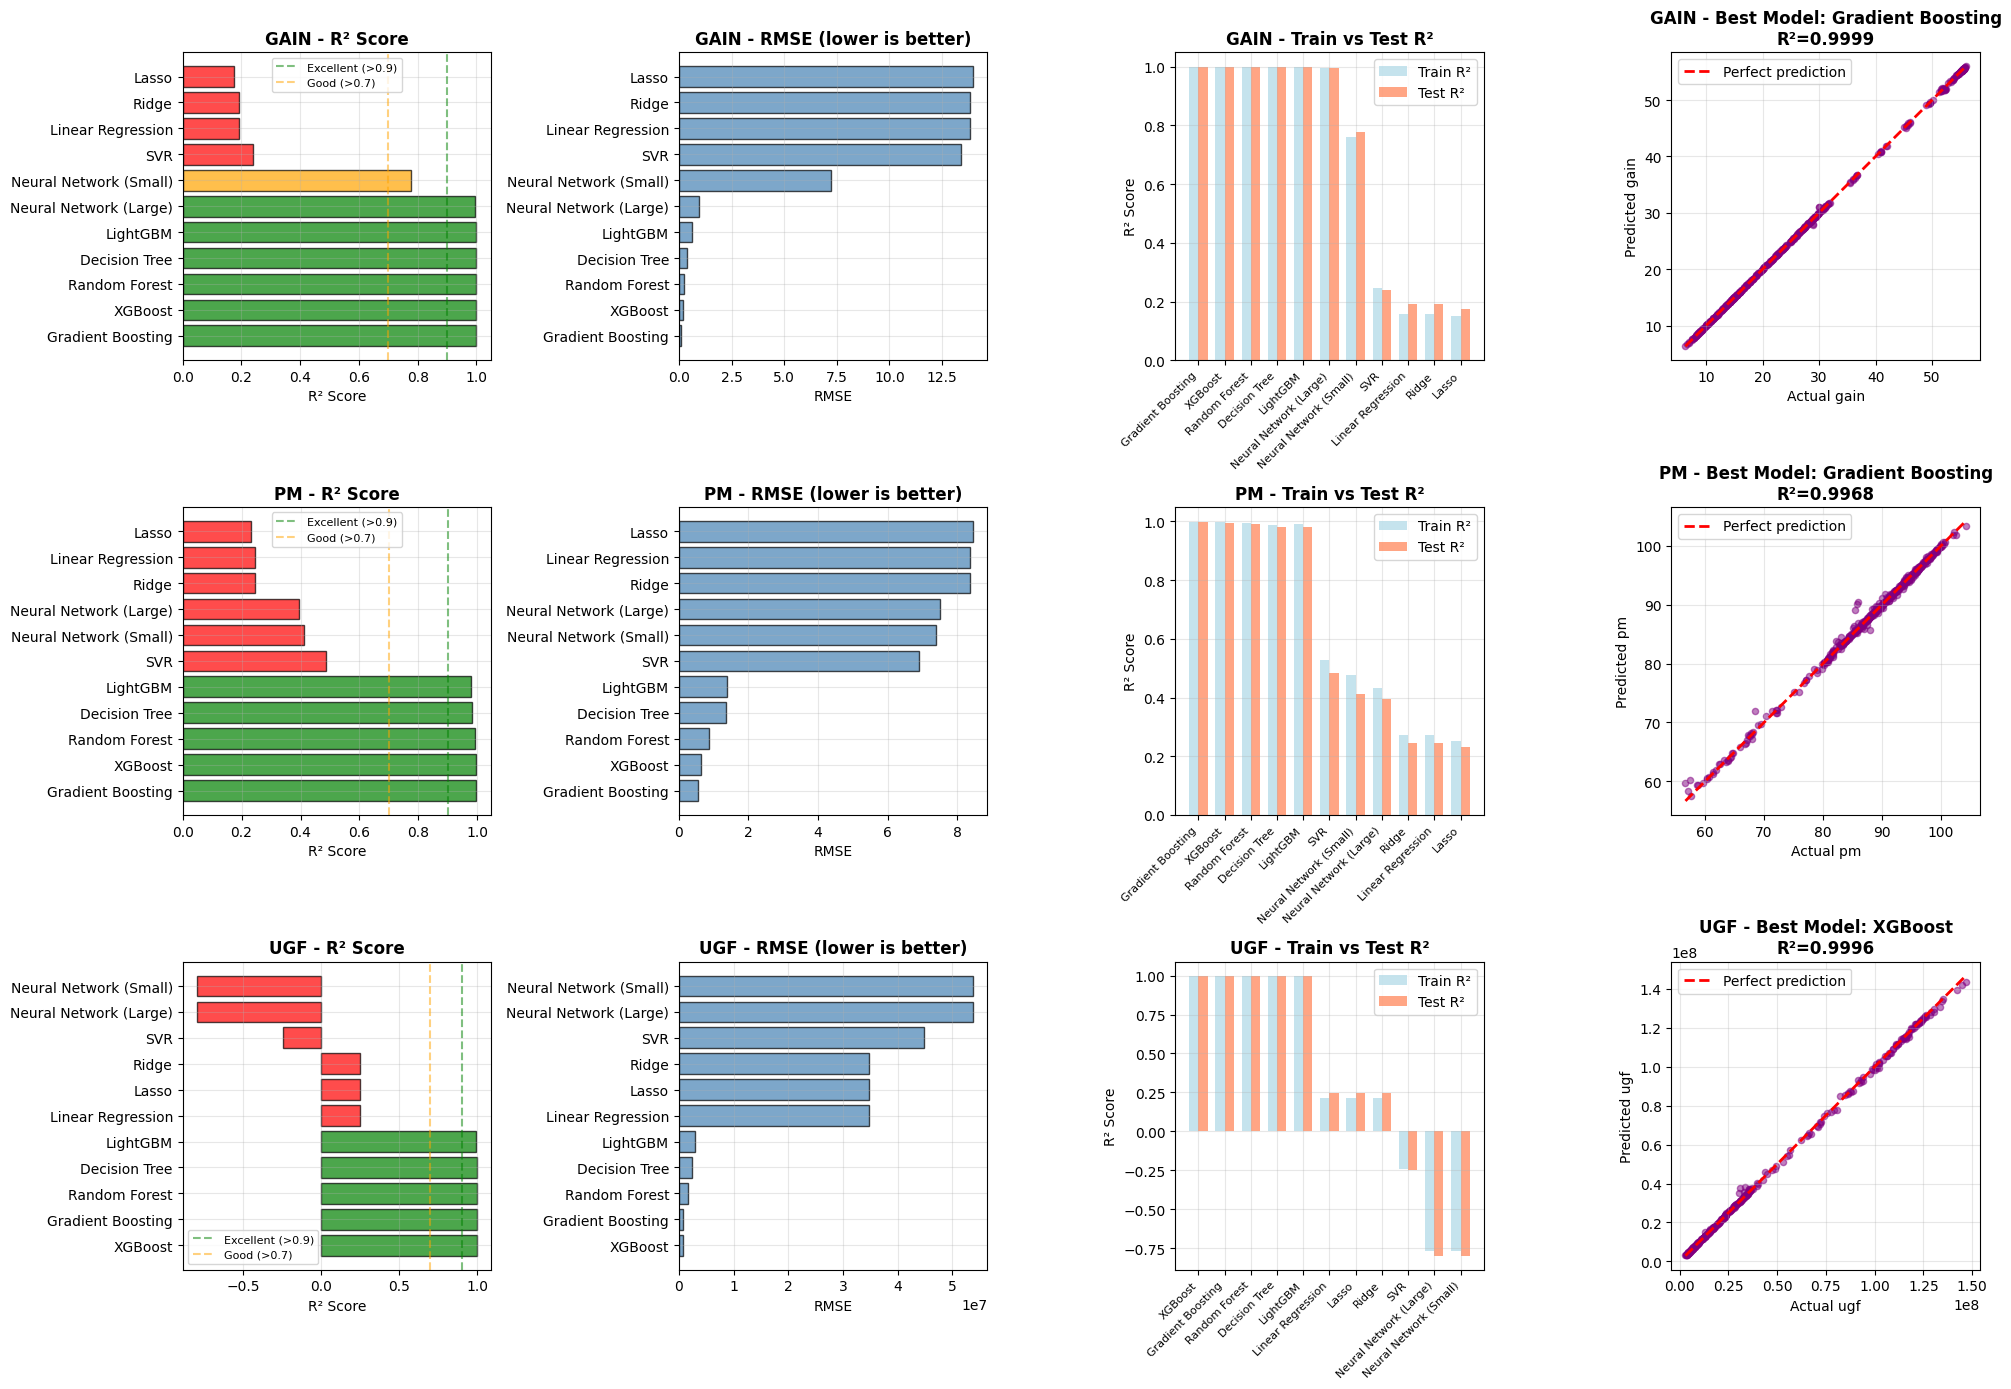

In [7]:

# ============================================================================
# STEP 6: VISUALIZE RESULTS
# ============================================================================

print("\n" + "="*80)
print("STEP 6: VISUALIZATION")
print("="*80)

# Create comprehensive visualization
fig = plt.figure(figsize=(20, 14))

# For each target
for idx, target_name in enumerate(['gain', 'pm', 'ugf']):
    target_results = results_df[results_df['target'] == target_name].copy()
    target_results = target_results.sort_values('test_r2', ascending=False)
    
    # 1. R² Score comparison
    ax1 = plt.subplot(3, 4, idx*4 + 1)
    models_list = target_results['model_name'].values
    r2_scores = target_results['test_r2'].values
    colors = ['green' if x > 0.9 else 'orange' if x > 0.7 else 'red' for x in r2_scores]
    ax1.barh(models_list, r2_scores, color=colors, alpha=0.7, edgecolor='black')
    ax1.set_xlabel('R² Score')
    ax1.set_title(f'{target_name.upper()} - R² Score', fontweight='bold')
    ax1.axvline(x=0.9, color='green', linestyle='--', alpha=0.5, label='Excellent (>0.9)')
    ax1.axvline(x=0.7, color='orange', linestyle='--', alpha=0.5, label='Good (>0.7)')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # 2. RMSE comparison
    ax2 = plt.subplot(3, 4, idx*4 + 2)
    rmse_scores = target_results['test_rmse'].values
    ax2.barh(models_list, rmse_scores, color='steelblue', alpha=0.7, edgecolor='black')
    ax2.set_xlabel('RMSE')
    ax2.set_title(f'{target_name.upper()} - RMSE (lower is better)', fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # 3. Train vs Test R² (check overfitting)
    ax3 = plt.subplot(3, 4, idx*4 + 3)
    train_r2 = target_results['train_r2'].values
    test_r2 = target_results['test_r2'].values
    x_pos = np.arange(len(models_list))
    width = 0.35
    ax3.bar(x_pos - width/2, train_r2, width, label='Train R²', alpha=0.7, color='lightblue')
    ax3.bar(x_pos + width/2, test_r2, width, label='Test R²', alpha=0.7, color='coral')
    ax3.set_ylabel('R² Score')
    ax3.set_title(f'{target_name.upper()} - Train vs Test R²', fontweight='bold')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(models_list, rotation=45, ha='right', fontsize=8)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Prediction scatter plot (best model only)
    ax4 = plt.subplot(3, 4, idx*4 + 4)
    best_result = target_results.iloc[0]
    y_true = best_result['actuals']
    y_pred = best_result['predictions']
    ax4.scatter(y_true, y_pred, alpha=0.5, s=20, color='purple')
    ax4.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 
             'r--', lw=2, label='Perfect prediction')
    ax4.set_xlabel(f'Actual {target_name}')
    ax4.set_ylabel(f'Predicted {target_name}')
    ax4.set_title(f'{target_name.upper()} - Best Model: {best_result["model_name"]}\n'
                  f'R²={best_result["test_r2"]:.4f}', fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_results.png', dpi=300, bbox_inches='tight')
print("\n✓ Comparison visualizations saved as 'model_comparison_results.png'")
plt.show()

In [8]:
# ============================================================================
# STEP 7: SUMMARY AND RECOMMENDATIONS
# ============================================================================

print("\n" + "="*80)
print("STEP 7: SUMMARY AND RECOMMENDATIONS")
print("="*80)

print("\n🎯 BEST MODELS FOR EACH TARGET:\n")

for target_name in ['gain', 'pm', 'ugf']:
    target_results = results_df[results_df['target'] == target_name].copy()
    target_results = target_results.sort_values('test_r2', ascending=False)
    
    best = target_results.iloc[0]
    second = target_results.iloc[1] if len(target_results) > 1 else None
    
    print(f"\n{target_name.upper()}:")
    print(f"  🥇 1st: {best['model_name']:<25} (R²={best['test_r2']:.4f}, RMSE={best['test_rmse']:.4f})")
    if second is not None:
        print(f"  🥈 2nd: {second['model_name']:<25} (R²={second['test_r2']:.4f}, RMSE={second['test_rmse']:.4f})")

# Overall recommendation
print("\n" + "="*80)
print("💡 RECOMMENDATIONS:")
print("="*80)

# Find models that perform well across all targets
print("\nModels with consistent performance across all targets:")
model_avg_r2 = results_df.groupby('model_name')['test_r2'].mean().sort_values(ascending=False)
print("\nAverage R² across all targets:")
for model_name, avg_r2 in model_avg_r2.head(5).items():
    print(f"  {model_name:<25} Avg R²: {avg_r2:.4f}")

# Check for overfitting
print("\nOverfitting Check (Train R² - Test R²):")
results_df['overfit_score'] = results_df['train_r2'] - results_df['test_r2']
overfitting = results_df.groupby('model_name')['overfit_score'].mean().sort_values()
print("\nModels with least overfitting (lower is better):")
for model_name, overfit in overfitting.head(5).items():
    print(f"  {model_name:<25} Overfit Score: {overfit:.4f}")

print("\n" + "="*80)
print("✅ MODEL EXPERIMENTATION COMPLETE!")
print("="*80)
print("\nNext steps:")
print("  1. Review the visualizations (model_comparison_results.png)")
print("  2. Choose the best models for gain, pm, and ugf")
print("  3. Proceed with optimization implementation using chosen models")
print("="*80)


STEP 7: SUMMARY AND RECOMMENDATIONS

🎯 BEST MODELS FOR EACH TARGET:


GAIN:
  🥇 1st: Gradient Boosting         (R²=0.9999, RMSE=0.1229)
  🥈 2nd: XGBoost                   (R²=0.9999, RMSE=0.1758)

PM:
  🥇 1st: Gradient Boosting         (R²=0.9968, RMSE=0.5472)
  🥈 2nd: XGBoost                   (R²=0.9958, RMSE=0.6218)

UGF:
  🥇 1st: XGBoost                   (R²=0.9996, RMSE=773702.2423)
  🥈 2nd: Gradient Boosting         (R²=0.9996, RMSE=802653.2526)

💡 RECOMMENDATIONS:

Models with consistent performance across all targets:

Average R² across all targets:
  Gradient Boosting         Avg R²: 0.9988
  XGBoost                   Avg R²: 0.9984
  Random Forest             Avg R²: 0.9966
  Decision Tree             Avg R²: 0.9922
  LightGBM                  Avg R²: 0.9908

Overfitting Check (Train R² - Test R²):

Models with least overfitting (lower is better):
  Linear Regression         Overfit Score: -0.0130
  Ridge                     Overfit Score: -0.0130
  Lasso                   